SCIPY

In [1]:
import matplotlib.pyplot as plt
import numpy as np

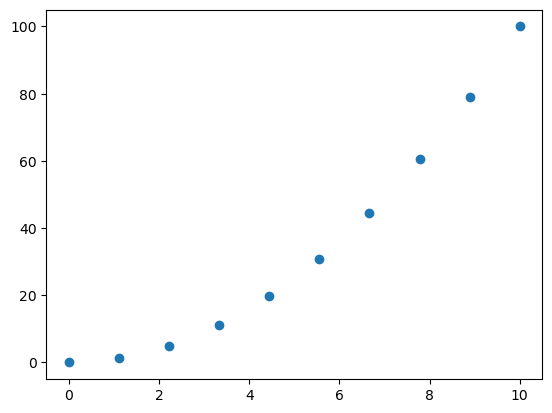

In [2]:
x = np.linspace(0, 10, 10)
y = x**2
plt.scatter(x,y)
plt.show()

(1) Interpolation   avec interplate   / lineaire / cubique / quadratique

In [3]:
from scipy.interpolate import interp1d

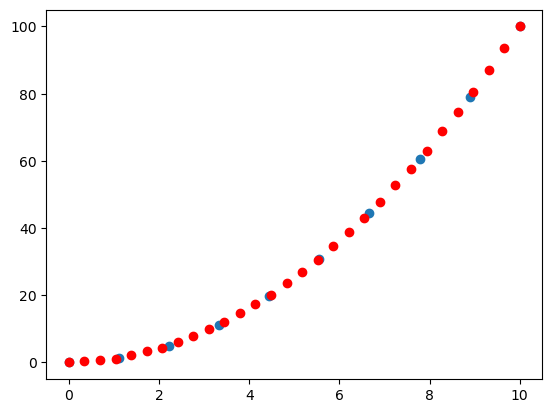

In [4]:
f = interp1d(x, y, kind='linear')     
new_x = np.linspace(0, 10, 30)
result = f(new_x)

plt.scatter(x, y)
plt.scatter(new_x, result, c='r')

Optimisation = problème de minimisation = trouver le minimum

In [5]:
def f(x, a, b, c, d):                        #réation du model
    return a*x**3 + b*x**2 + c*x + d

In [6]:
from scipy import optimize

In [7]:
optimize.curve_fit(f, x, y)      #la foncyion curv_fit utilise la méthode de moindre carrée

(array([ 6.23378615e-09,  9.99999905e-01,  3.61365981e-07, -2.39006460e-07]),
 array([[ 1.69508519e-17, -1.98704820e-16,  5.17538500e-16,
         -2.87456101e-16],
        [-1.98704820e-16,  2.36008904e-15, -6.34638908e-15,
          3.71063905e-15],
        [ 5.17538500e-16, -6.34638908e-15,  1.85716995e-14,
         -1.26618891e-14],
        [-2.87456101e-16,  3.71063905e-15, -1.26618891e-14,
          1.46384908e-14]]))

In [8]:
params, param_cov = optimize.curve_fit(f, x, y)   #on enregistre les deux tableau dans les variables

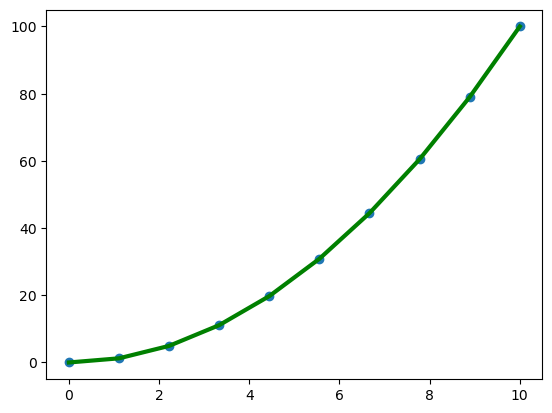

In [9]:
plt.scatter(x, y)
plt.plot(x, f(x, params[0], params[1],params[2], params[3]), c='g', lw=3)

MINIMISATION

In [10]:
def f(x):
    return x**2 + 15*np.sin(x)

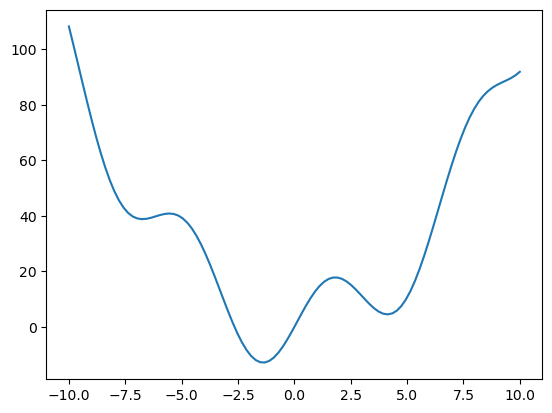

In [11]:
x = np.linspace(-10, 10, 100)
plt.plot(x, f(x))

In [12]:
#trouvons le minimum à partir d un point de départ(x_0= -8)

In [13]:
optimize.minimize(f, x0=-8)   #minimum local

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 38.81120617595851
        x: [-6.738e+00]
      nit: 6
      jac: [ 4.768e-07]
 hess_inv: [[ 1.164e-01]]
     nfev: 14
     njev: 7

In [14]:
optimize.minimize(f, x0=-5)   #minimum global

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -12.823616887804414
        x: [-1.385e+00]
      nit: 4
      jac: [ 3.695e-06]
 hess_inv: [[ 5.979e-02]]
     nfev: 18
     njev: 9

In [15]:
x0 = -5
result = optimize.minimize(f, x0=x0).x

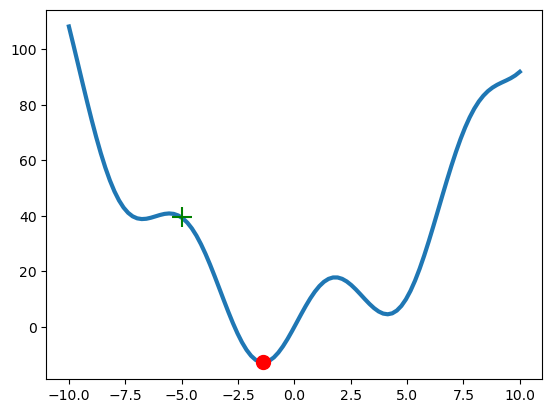

In [16]:
plt.plot(x, f(x), lw =3, zorder =-1)
plt.scatter(result, f(result), s=100, c ='r', zorder=-1)
plt.scatter(x0, f(x0), s= 200, marker='+', c='g', zorder=-1)
plt.show()

Traitement du signal 

In [17]:
#ff      ta

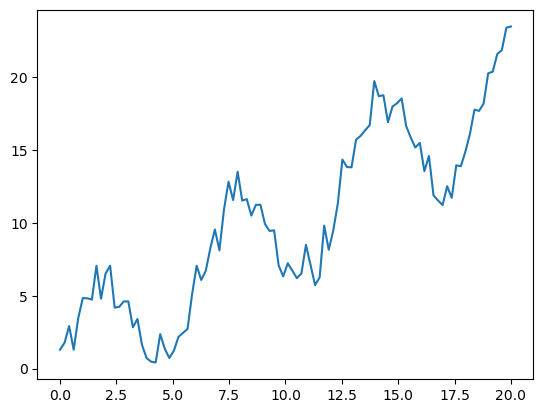

In [22]:
x = np.linspace(0, 20, 100)
y = x + 4*np.sin(x) +np.random.randn(x.shape[0])
plt.plot(x, y)
plt.show()

In [23]:
#éliminer la tendance lineaire

In [26]:
from scipy import signal

In [27]:
new_y = signal.detrend(y)

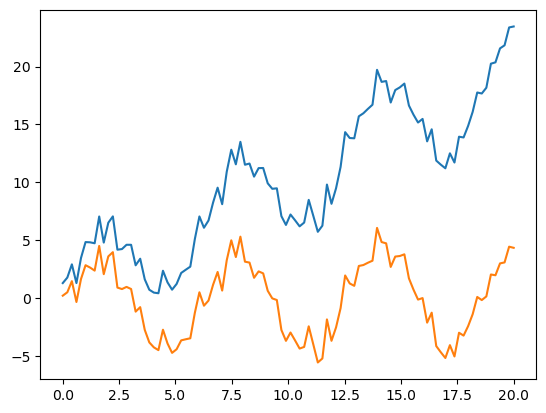

In [28]:
plt.plot(x, y)
plt.plot(x, new_y)

In [30]:
# transformation des fouriere = extraire la fréquence

In [31]:
# avce la fontion ffpack.fft ()

In [32]:
# avce la fontion ffpack.fftfreq()

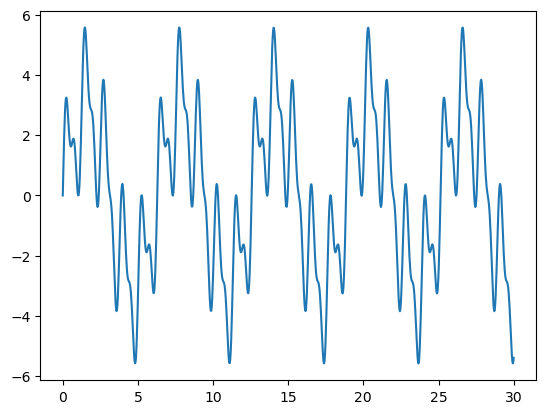

In [34]:
x = np.linspace(0, 30, 1000)
y = 3*np.sin(x) + 2*np.sin(5*x) + np.sin(10*x)
plt.plot(x, y)

In [35]:
from scipy import fftpack

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


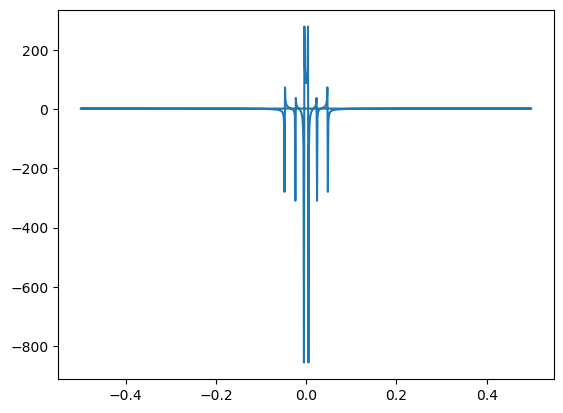

In [38]:
fourier = fftpack.fft(y)
frequences = fftpack.fftfreq(y.size)
plt.plot(frequences, fourier)

In [39]:
#pour filtrer les amplitude négative

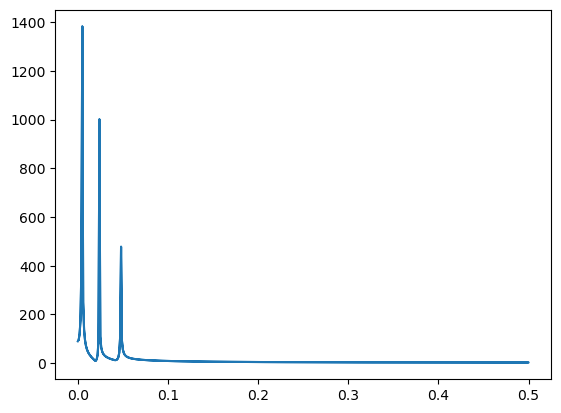

In [41]:
fourier = fftpack.fft(y)
power = np.abs(fourier)
frequences = fftpack.fftfreq(y.size)
plt.plot(np.abs(frequences, fourier), power)

EXERCICE SUR LA TRANSFORMATION DE FOURIER

In [ ]:
#ON  DONNE UN SIGNAL 

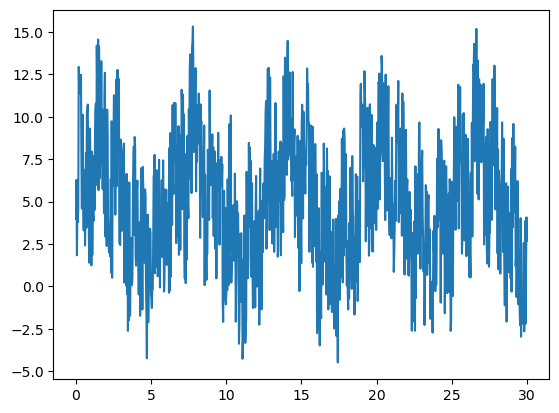

In [83]:
x = np.linspace(0, 30, 1000)
y = 3*np.sin(x) + 2*np.sin(5*x) + np.sin(10*x) + np.random.random(x.shape[0])*10
plt.plot(x, y)

In [84]:
# on applique la transformer de fourier

In [85]:
from scipy import fftpack

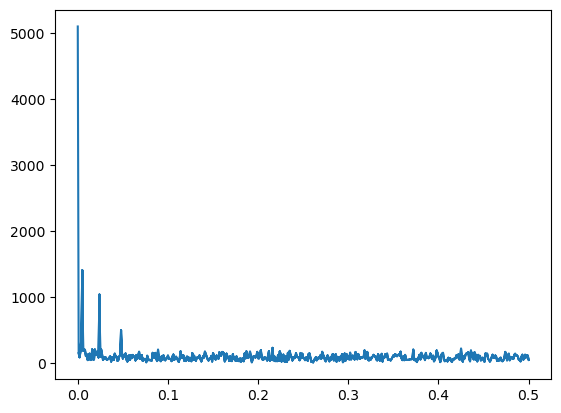

In [86]:
fourier = fftpack.fft(y)
power = np.abs(fourier)
frequences = fftpack.fftfreq(y.size)
plt.plot(np.abs(frequences, fourier), power)

In [87]:
# on doit filter ce spectre

In [88]:
fourier[power<400] = 0

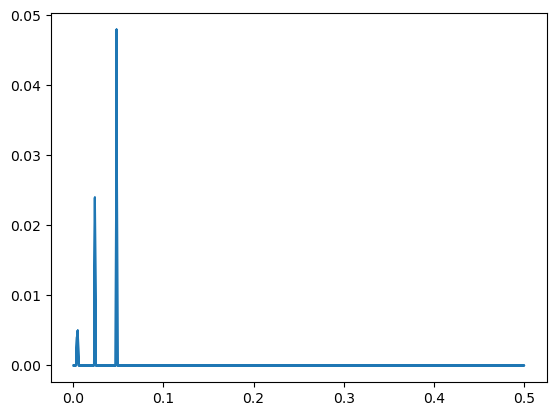

In [89]:
plt.plot(np.abs(frequences), np.abs(fourier))

In [90]:
# APPLIQUER LA TRANSFORMÉ DE FOURIER INVERSE

In [91]:
filtered_signal = fftpack.ifft(fourier)

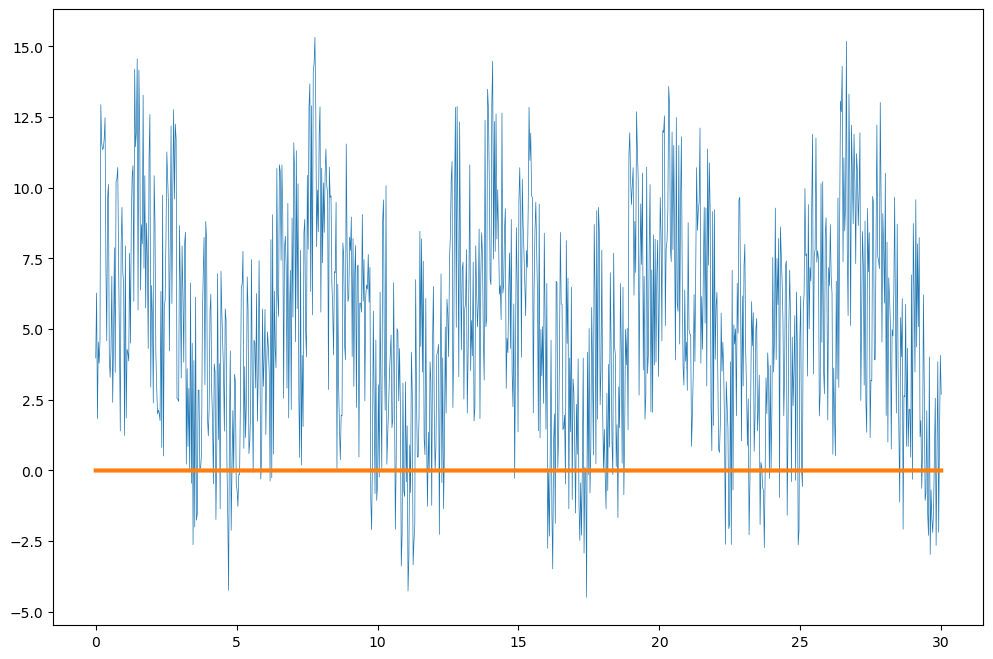

In [92]:
plt.figure(figsize=(12, 8))
plt.plot(x, y, lw=0.5)
plt.plot(x, filtered_signal, lw=3)
plt.show()

TRAITEMENT D IMAGE

In [148]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

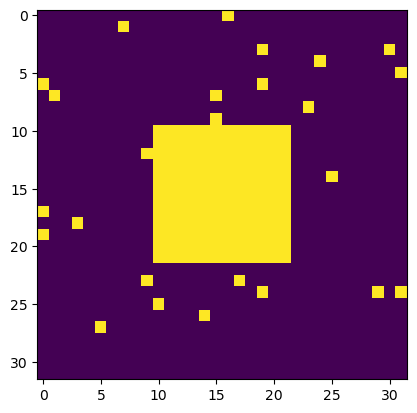

In [149]:
np.random.seed(0)
x = np.zeros((32, 32))
x[10:-10, 10:-10] = 1
x[np.random.randint(0, 32, 30), np.random.randint(0,32,30)] = 1
plt.imshow(x)

In [150]:
# retirer les pixels artefact

In [151]:
#combiner l érosion et un dilation

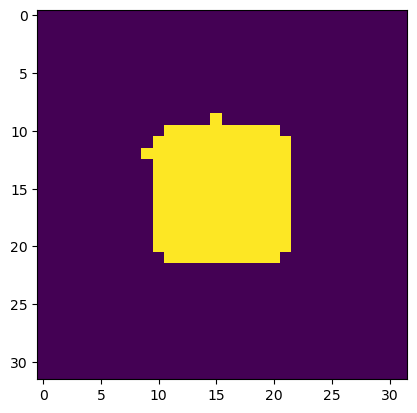

In [152]:
open_x = ndimage.binary_opening(x)
plt.imshow(open_x)

In [155]:
label_image, n_labels = ndimage.label(x)
print(n_labels)

24


In [156]:
sizes = ndimage.sum(open_x, label_image, range(n_labels))

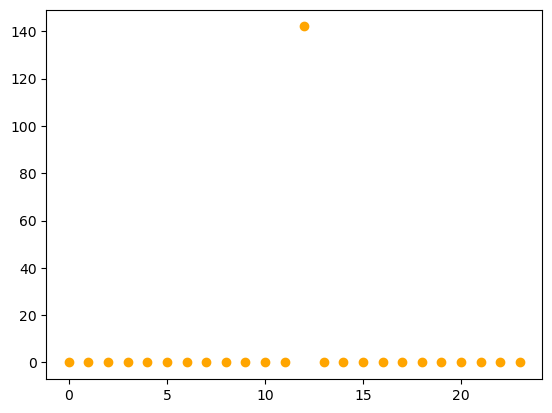

In [157]:
plt.scatter(range(n_labels), sizes, c ='orange')

APPLICATION

(507, 537, 3)

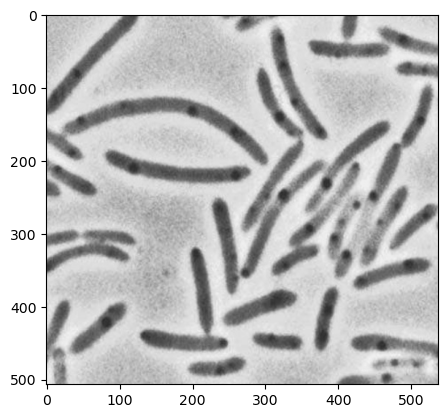

In [158]:
image = plt.imread('bacteria.png')
plt.imshow(image)
image.shape

In [159]:
#limage est en 3D on va reduire en 2D

(427, 472)

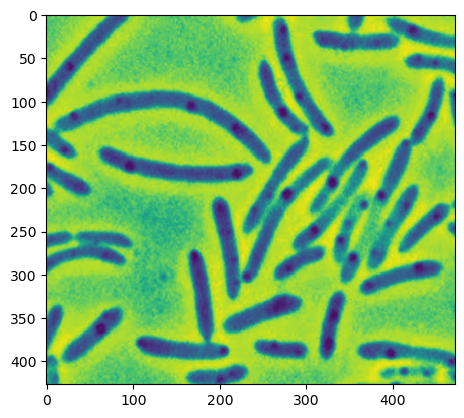

In [160]:
image = plt.imread('im.jpg')
image = image[:,:,0]
plt.imshow(image)
image.shape

In [161]:
#0001 extraire les bacterrier de l ariiere plan

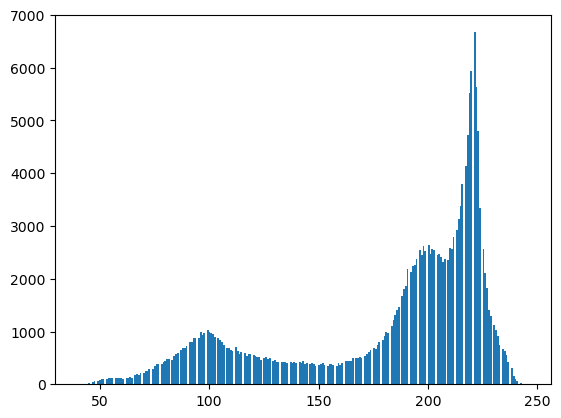

In [162]:
image_2 = np.copy(image)
plt.hist(image_2.ravel(), bins =255)
plt.show()

In [163]:
label_image, n_labels = ndimage.label(image)
print(n_labels)

1


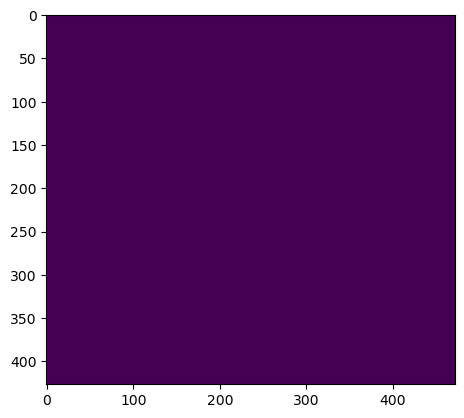

In [164]:
plt.imshow(label_image)

1
